# Test Single Sample — DDPM Image Generation
Fahad Khalid | MSDS25025 | Deep Learning Assignment 5 (Bonus)

This notebook loads the trained model from `saved_models/ddpm.pth` and generates an image from pure noise. It is fully self-contained (cold-load).

In [1]:
import torch
import matplotlib.pyplot as plt
from MSDS25025_05 import UNet, sample, device, IMG_SIZE, T
print('Imports OK | device:', device)

Imports OK | device: cuda


## 1. Load the trained model (weights only)

In [2]:
model = UNet().to(device)
model.load_state_dict(torch.load('saved_models/ddpm.pth', map_location=device))
model.eval()
print('Loaded trained weights from saved_models/ddpm.pth')

Loaded trained weights from saved_models/ddpm.pth


## 2. Generate a single image from pure noise

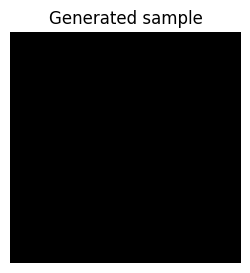

In [3]:
gen, frames = sample(model, n=1, save_every=200)

plt.figure(figsize=(3, 3))
plt.imshow(((gen[0] + 1) / 2).permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.title('Generated sample')
plt.show()

## 3. Show the denoising trajectory (noise -> image)

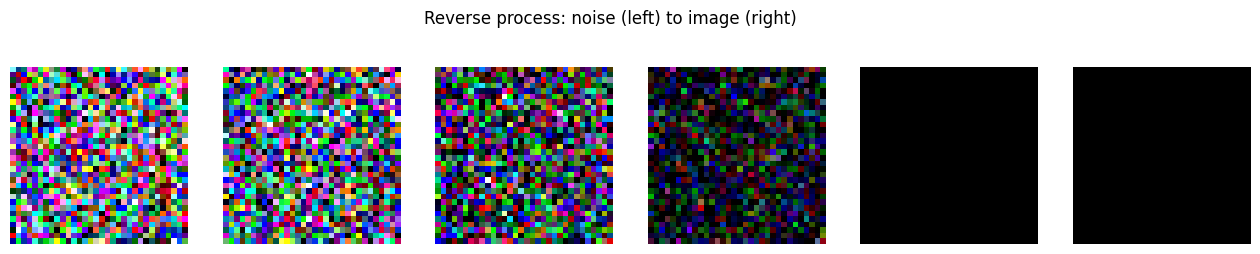

In [4]:
trajectory = frames + [gen.cpu()]
fig, axes = plt.subplots(1, len(trajectory), figsize=(16, 3))
for ax, fr in zip(axes, trajectory):
    ax.imshow(((fr[0] + 1) / 2).permute(1, 2, 0).numpy())
    ax.axis('off')
plt.suptitle('Reverse process: noise (left) to image (right)')
plt.show()